In [24]:
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Toy simulator

In [25]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel

t_min = -1
t_max = 1
n_t = 64
counts_min = 100
counts_max = 100
fwhm_psf = 0.1
pixel_size = (t_max - t_min) / n_t

bins = np.linspace(t_min, t_max, n_t + 1)

sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluc=True):
    
    mu_iso = np.random.uniform(0, 50)
    z_n_mu = np.random.uniform(0, 100)
    z_n = np.random.poisson(z_n_mu)
            
    z_x = np.random.uniform(t_min, t_max, size=(2, z_n))
    z_c = np.random.uniform(counts_min, counts_max, z_n)

    mu_bkg = mu_iso * np.ones((n_t, n_t))

    if z_n > 0:
        mu_signal = binned_statistic_2d(x=z_x[0], y=z_x[1], values=z_c, statistic='sum', bins=bins).statistic
        counts_binned = (mu_bkg + convolve(mu_signal, kernel))
    else:
        counts_binned = (mu_bkg)

    if poiss_fluc:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        plt.imshow(counts_binned)
    
    return z_n_mu, mu_iso, counts_binned

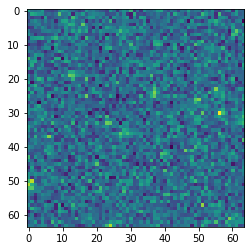

In [26]:
_, _, x = simulate(plot=True)

In [27]:
from scipy import stats

def power_spectrum(x):
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

In [28]:
from tqdm.notebook import tqdm

simulations = [simulate() for _ in tqdm(range(20000))]
x = list(map(itemgetter(2), simulations))
mu_z_n = list(map(itemgetter(0), simulations))
mu_iso = list(map(itemgetter(1), simulations))
x_f = np.array([power_spectrum(x_i) for x_i in x])

  0%|          | 0/20000 [00:00<?, ?it/s]

Text(0.5, 1.0, 'Mean power spectrum')

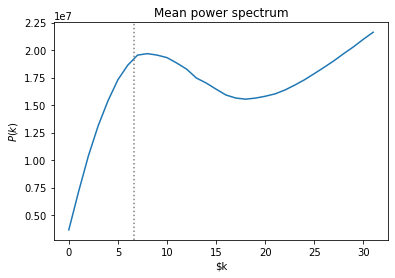

In [29]:
plt.plot(np.mean(x_f, axis=0))
plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k")
plt.ylabel("$P(k)$")
plt.title("Mean power spectrum")

## Mutual information

$$\mathrm{MI}(X ; Y)=D_{\mathrm{KL}}\left(P_{(X, Y)} \| P_{X} \otimes P_{Y}\right)$$

$$\mathrm{MI}(X ; Y)=\int_{\mathcal{Y}} \int_{\mathcal{X}} p_{(X, Y)}(x, y) \log \left(\frac{p_{(X, Y)}(x, y)}{p_{X}(x) p_{Y}(y)}\right) d x d y$$

In [30]:
def calc_MI(X,Y,bins):
    c_XY = np.histogram2d(X,Y,bins)[0]
    c_X = np.histogram(X,bins)[0]
    c_Y = np.histogram(Y,bins)[0]

    H_X = shannon_entropy(c_X)
    H_Y = shannon_entropy(c_Y)
    H_XY = shannon_entropy(c_XY)

    MI = H_X + H_Y - H_XY
    return MI

def shannon_entropy(c):
    c_normalized = c / float(np.sum(c))
    c_normalized = c_normalized[np.nonzero(c_normalized)]
    H = -sum(c_normalized* np.log2(c_normalized))  
    return H

In [31]:
# from sklearn.metrics import mutual_info_score

# def calc_MI(x, y, bins):
#     c_xy = np.histogram2d(x, y, bins)[0]
#     mi = mutual_info_score(None, None, contingency=c_xy)
#     return mi

Text(0, 0.5, 'MI')

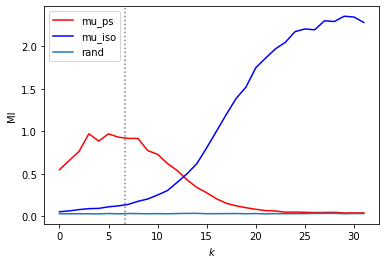

In [32]:
n_bins = 32

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n, x_f[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f[:, i], mu_iso, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f[:, i], np.random.uniform(0, 3, size=x_f[:, i].shape), n_bins))
    
plt.plot(MI, label="rand")

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

## ResNet

In [33]:
import sys
sys.path.append("../")
from models.resnet import ResNetEstimator

In [34]:
import torch
import torch.nn as nn

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, StochasticWeightAveraging
from pytorch_lightning.loggers import MLFlowLogger

from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [35]:
class ResNetRegressor(pl.LightningModule):
    def __init__(self, n_out=2):
        super().__init__()
        
        self.save_hyperparameters()
        
        self.resnet = ResNetEstimator(cfg=18, n_out=n_out, log_input=False)
        self.loss = nn.MSELoss()
        
    def forward(self, x):
        x = self.resnet(x)
        return x
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('train_loss', loss.mean(), on_epoch=True)
                
        return loss.mean()
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('val_loss', loss.mean(), on_epoch=True)
        return loss.mean()

In [36]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

y = torch.Tensor(np.array([mu_z_n, mu_iso])).T
y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y = (y - y_mean) / y_std

x = torch.Tensor(x)

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=16, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=16, shuffle=False)

/tmp/ipykernel_60006/1271055470.py:9: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  ../torch/csrc/utils/tensor_new.cpp:201.)
  x = torch.Tensor(x)
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [37]:
# pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

model = ResNetRegressor()

In [38]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=1, gradient_clip_val=0.2, callbacks=[checkpoint_callback,],)
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name   | Type            | Params
-------------------------------------------
0 | resnet | ResNetEstimator | 12.2 M
1 | loss   | MSELoss         | 0     
-------------------------------------------
12.2 M    Trainable params
0         Non-trainable params
12.2 M    Total params
48.900    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [39]:
simulations_test = [simulate() for _ in range(5000)]
x_test = list(map(itemgetter(2), simulations_test))
mu_z_n_test = list(map(itemgetter(0), simulations_test))
mu_iso_test = list(map(itemgetter(1), simulations_test))
x_f_test = np.array([power_spectrum(x_i) for x_i in x_test])

In [40]:
y_test =  torch.Tensor(np.array([mu_z_n_test, mu_iso_test])).T
y_test = (y_test - y_mean) / y_std

In [41]:
x_test = torch.Tensor(x_test)

In [42]:
dataset_test = TensorDataset(x_test, y_test)
test_loader = DataLoader(dataset_test, batch_size=256, num_workers=1, shuffle=False)

In [43]:
mu_z_n_test, mu_iso_test = y_test.detach().numpy().T

In [44]:
model.to('cuda')

mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, y_b = batch
        mu_pred.append(model(x_b.to('cuda')).cpu())
    del x_b

  0%|          | 0/20 [00:00<?, ?it/s]

In [45]:
mu_z_n_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

Text(0, 0.5, '$\\mu_{ps, pred}$')

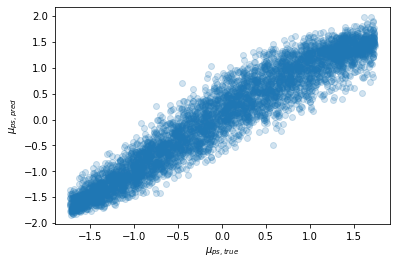

In [46]:
plt.scatter(mu_z_n_test, mu_z_n_pred, alpha=0.2)
plt.xlabel(r"$\mu_{ps, true}$")
plt.ylabel(r"$\mu_{ps, pred}$")

Text(0, 0.5, '$\\mu_{iso, pred}$')

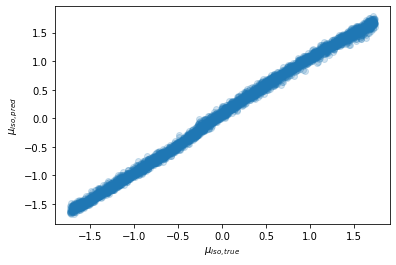

In [47]:
plt.scatter(mu_iso_test, mu_iso_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

Text(0, 0.5, 'MI')

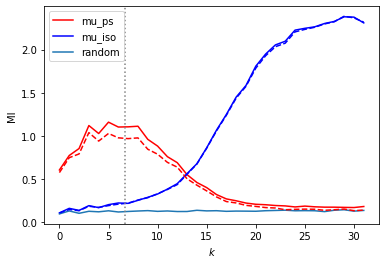

In [48]:
n_bins = 32

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n_pred, x_f_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], np.random.uniform(0, 3, size=x_f_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n_test, x_f_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

## PCANet

In [49]:
from sklearn.decomposition import PCA, IncrementalPCA

In [50]:
pca = PCA(n_components=64)

In [51]:
x_flattened = x.reshape(-1, n_t * n_t)
x_pca = pca.fit_transform(x_flattened)
x_pca = (x_pca - x_pca.mean(axis=0)) / x_pca.std(axis=0)

In [52]:
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel("n_components")
# plt.ylabel("% variance explained")

In [53]:
from torch import nn, tanh, relu

def build_mlp(input_dim, hidden_dim, output_dim, layers, activation):
    """Create a mlp from the configurations."""
    activation = {
        'relu': nn.ReLU
    }[activation]

    seq = [nn.Linear(input_dim, hidden_dim), activation()]
    for _ in range(layers):
        seq += [nn.Linear(hidden_dim, hidden_dim), activation()]
    seq += [nn.Linear(hidden_dim, output_dim)]

    return nn.Sequential(*seq)

In [54]:
class PCANet(pl.LightningModule):
    def __init__(self, n_out=2):
        super().__init__()
        
        self.save_hyperparameters()
        
        self.mlp = build_mlp(64, 128, n_out, 4, 'relu')
        self.loss = nn.MSELoss()
        
    def forward(self, x):
        x = self.mlp(x)
        return x
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('train_loss', loss.mean(), on_epoch=True)
                
        return loss.mean()
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('val_loss', loss.mean(), on_epoch=True)
        return loss.mean()

In [55]:
dataset = TensorDataset(torch.Tensor(x_pca), y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=16, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=16, shuffle=False)

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/torch/utils/data/dataloader.py:478: UserWarning: This DataLoader will create 16 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [56]:
pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

model = PCANet()

Global seed set to 576


In [57]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=0, gradient_clip_val=0.2, callbacks=[checkpoint_callback,],)
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/trainer/trainer.py:1303: UserWarning: GPU available but not used. Set the gpus flag in your trainer `Trainer(gpus=1)` or script `--gpus=1`.
  rank_zero_warn(
Set SLURM handle signals.

  | Name | Type       | Params
------------------------------------
0 | mlp  | Sequential | 74.6 K
1 | loss | MSELoss    | 0     
------------------------------------
74.6 K    Trainable params
0         Non-trainable params
74.6 K    Total params
0.299     Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Global seed set to 576


Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [58]:
x_test_flattened = x_test.reshape(-1, n_t * n_t)
x_test_pca = pca.fit_transform(x_test_flattened)
x_test_pca = (x_test_pca - x_pca.mean(axis=0)) / x_pca.std(axis=0)

In [59]:
dataset_test = TensorDataset(torch.Tensor(x_test_pca), y_test)
test_loader = DataLoader(dataset_test, batch_size=256, num_workers=1, shuffle=False)

In [60]:
mu_z_n_test, mu_iso_test = y_test.detach().numpy().T

In [61]:
mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, y_b = batch
        mu_pred.append(model(x_b))
    del x_b

  0%|          | 0/20 [00:00<?, ?it/s]

In [62]:
mu_z_n_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

In [63]:
# plt.scatter(mu_z_n_test, mu_z_n_pred, alpha=0.2)
# plt.xlabel(r"$\mu_{ps, true}$")
# plt.ylabel(r"$\mu_{ps, pred}$")

In [64]:
# plt.scatter(mu_iso_test, mu_iso_pred, alpha=0.2)
# plt.xlabel(r"$\mu_{iso, true}$")
# plt.ylabel(r"$\mu_{iso, pred}$")

Text(0, 0.5, 'MI')

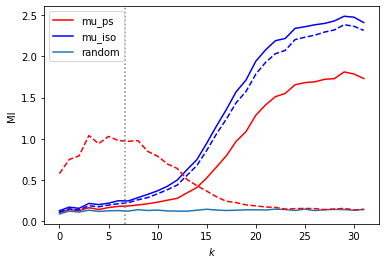

In [65]:
n_bins = 32

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n_pred, x_f_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], np.random.uniform(0, 3, size=x_f_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n_test, x_f_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

## $P(k)$-guided learning

In [130]:
class DistanceCorrelation(nn.Module):
    def __init__(self):
        super(DistanceCorrelation, self).__init__()

    def forward(self, A, B):
        '''
        Calculate the Distance Correlation between the two vectors. https://en.wikipedia.org/wiki/Distance_correlation
        Value of 0 implies independence. A and B can be vectors of different length.
        :param A:    vector A of shape (num_samples, sizeA)
        :param B:    vector B of shape (num_samples, sizeB)
        :return:     the distance correlation between A and B
        '''
        a = self._distance_matrix(A)
        b = self._distance_matrix(B)
        dist_cov2_ab = torch.clamp(torch.div(torch.sum(a * b), A.shape[0] * A.shape[0]), 1e-10, 1e10)
        dist_cov2_aa = torch.clamp(torch.div(torch.sum(a * a), A.shape[0] * A.shape[0]), 1e-10, 1e10)
        dist_cov2_bb = torch.clamp(torch.div(torch.sum(b * b), A.shape[0] * A.shape[0]), 1e-10, 1e10)
        dist_var_prod= torch.clamp(torch.sqrt(dist_cov2_aa) * torch.sqrt(dist_cov2_bb), 1e-10, 1e10)
        dist_cor = torch.div(torch.sqrt(dist_cov2_ab), torch.sqrt(dist_var_prod))
        return dist_cor

    def _distance_matrix(self, x):
        '''
        Input: x is a Nxd matrix
            y is an optional Mxd matirx
        Output: dist is a NxM matrix where dist[i,j] is the square norm between x[i,:] and y[j,:]
                if y is not given then use 'y=x'.
        i.e. dist[i,j] = ||x[i,:]-y[j,:]||^2
        '''
        x_norm = (x**2).sum(1).view(-1, 1)
        y_t = torch.transpose(x, 0, 1)
        y_norm = x_norm.view(1, -1)
        
        dist = x_norm + y_norm - 2.0 * torch.mm(x, y_t)
        # Ensure diagonal is zero if x=y
        # if y is None:
        #     dist = dist - torch.diag(dist.diag)
        dist = torch.clamp(dist, 0.0, np.inf)
        dist = torch.sqrt(torch.clamp(dist, 1e-10, 1e10))
        rows_mean = torch.mean(dist, 0, True)
        columns_mean = torch.mean(dist, 1, True)
        distance = dist - rows_mean - columns_mean + torch.mean(dist)
        return distance
        # z = torch.sum(x * x, 1)
        # #a = tf.reshape(a, [-1, 1])
        # z = z.view(-1, 1)
        # dZ_sq = z - 2 * torch.mm(x, x.t()) + z.t()
        # dZ = torch.sqrt(torch.clamp(dZ_sq, 1e-10, 1e10))

        # dZ_mean_row = torch.mean(dZ, 0, True)
        # dZ_mean_column = torch.mean(dZ, 1, True)
        # dZ_total_mean = torch.mean(dZ)
        # dZ = dZ - dZ_mean_row - dZ_mean_column + dZ_total_mean
        # return dZ


In [203]:
class PCANetMI(pl.LightningModule):
    def __init__(self, n_out=2):
        super().__init__()
        
        self.save_hyperparameters()
        
        self.mlp = build_mlp(64, 128, n_out, 4, 'relu')
        self.mse_loss = nn.MSELoss()
        
        self.dcor = DistanceCorrelation()
        
        self.loss_mi_list = []
        
    def forward(self, x):
        x = self.mlp(x)
        return x
    
    def loss(self, x_f, y, out):
        
        loss = self.mse_loss(y, out)
         
        loss_mi = 0
        
        mi_true = self.mi(x_f[:], y[:,])
        mi_pred = self.mi(x_f[:], out[:])
        
        loss_mi = self.mse_loss(mi_true, mi_pred)
        
#         for i in range(32):
            
#             mi_true = self.mi(x_f[:, i], y[:,0])
#             mi_pred = self.mi(x_f[:, i], out[:,0])

#             loss_mi += self.mse_loss(mi_true, mi_pred)
            
#         print(loss, loss_mi)
        return loss, loss_mi
    
    def mi(self, X, Y):
#         return torch.cdist(X, Y)
        return self.dcor(X, Y)
#         return calc_MI_torch(X, Y, 32)
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, x_f, y = batch
        out = self(x)     
        loss, loss_mi = self.loss(x_f, y, out)
        self.log('train_loss', loss_mi, on_epoch=True)
        self.loss_mi_list.append(loss_mi)
        return loss_mi
    
    def validation_step(self, batch, batch_idx):
        x, x_f, y = batch
        out = self(x)     
        loss, loss_mi = self.loss(x_f, y, out)
        self.log('val_loss', loss + loss_mi, on_epoch=True)
        return loss + loss_mi

In [204]:
dataset = TensorDataset(torch.Tensor(x_pca), torch.Tensor(x_f), y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=16, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=16, shuffle=False)

In [205]:
pl.utilities.seed.seed_everything(seed=np.random.randint(638))  # Set universal seed

model = PCANetMI()

Global seed set to 225


In [206]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=10, gpus=0, gradient_clip_val=0.2, callbacks=[checkpoint_callback,],)
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
Set SLURM handle signals.

  | Name     | Type                | Params
-------------------------------------------------
0 | mlp      | Sequential          | 74.6 K
1 | mse_loss | MSELoss             | 0     
2 | dcor     | DistanceCorrelation | 0     
-------------------------------------------------
74.6 K    Trainable params
0         Non-trainable params
74.6 K    Total params
0.299     Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Global seed set to 225


Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

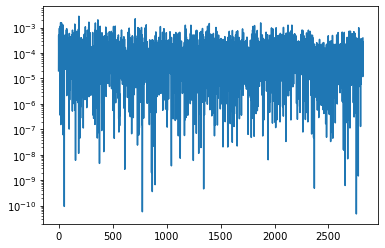

In [207]:
plt.plot([loss.detach().numpy() for loss in model.loss_mi_list])
plt.yscale("log")

In [208]:
mu_pred = []
for batch in tqdm(test_loader):
    with torch.no_grad():
        x_b, y_b = batch
        mu_pred.append(model(x_b))
    del x_b

  0%|          | 0/20 [00:00<?, ?it/s]

In [209]:
mu_z_n_pred, mu_iso_pred = torch.cat(mu_pred).detach().numpy().T

Text(0, 0.5, '$\\mu_{iso, pred}$')

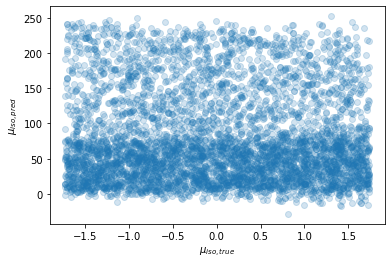

In [210]:
plt.scatter(mu_z_n_test, mu_z_n_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

Text(0, 0.5, '$\\mu_{iso, pred}$')

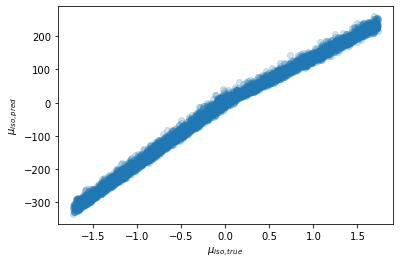

In [211]:
plt.scatter(mu_iso_test, mu_iso_pred, alpha=0.2)
plt.xlabel(r"$\mu_{iso, true}$")
plt.ylabel(r"$\mu_{iso, pred}$")

Text(0, 0.5, 'MI')

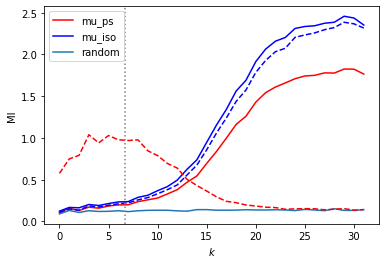

In [212]:
n_bins = 32

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n_pred, x_f_test[:, i], n_bins))
    
plt.plot(MI, label="mu_ps", color='red')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], mu_iso_pred, n_bins))
    
plt.plot(MI, label="mu_iso", color='blue')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], np.random.uniform(0, 3, size=x_f_test[:, i].shape), n_bins))
    
plt.plot(MI, label="random")

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(mu_z_n_test, x_f_test[:, i], n_bins))
    
plt.plot(MI, color='red', ls='--')

MI = []
for i in range(len(x_f[0, :])):
    MI.append(calc_MI(x_f_test[:, i], mu_iso_test, n_bins))
    
plt.plot(MI, color='blue', ls='--')

plt.legend()

plt.axvline(2 * np.pi / (sigma_psf / pixel_size), ls=':', color='grey', alpha=1)

plt.xlabel("$k$")
plt.ylabel("MI")

In [67]:
from models.histogramdd import histogramdd
import torchist

In [68]:
calc_MI(mu_iso_pred, x_f_test[:, i], 32)

2.4112492775033942

In [73]:
calc_MI_torch(torch.Tensor(mu_iso_pred), torch.Tensor(x_f_test[:, i]),  32)

tensor(2.4112)

In [146]:
from torch.autograd import grad
x = autodiff_test(torch.Tensor(mu_iso_pred).to('cuda'))
grad(x, mu)

In [70]:
def calc_MI_torch(X, Y, bins=32):

    c_XY = torchist.histogramdd(torch.vstack([X, Y]).T, 32)
    c_X = torchist.histogram(X,bins)
    c_Y = torchist.histogram(Y,bins)
        
    H_X = shannon_entropy_torch(c_X)
    H_Y = shannon_entropy_torch(c_Y)
    H_XY = shannon_entropy_torch(c_XY)
    
    MI = H_X + H_Y - H_XY
    return MI

def shannon_entropy_torch(c):
    c_normalized = c / torch.sum(c)
    c_normalized = c_normalized[torch.nonzero(c_normalized, as_tuple=True)]
    H = -torch.sum(c_normalized * torch.log2(c_normalized))  
    return H

In [3]:
from kornia.enhance import histogram2d

In [21]:
histogram2d(torch.Tensor(mu_z_n).unsqueeze(0), torch.Tensor(x_f[:, 0]).unsqueeze(0), torch.linspace(0, , 0)

SyntaxError: invalid syntax (1372670118.py, line 2)